In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### TENSORS - PyTorch's Basic Building Block

In [7]:
print("\n" + "="*60)
print("TENSORS (PyTorch's NumPy)")
print("="*60)

# Tensors are like NumPy arrays but on steroids!
print("Creating tensors:")

# From list
tensor1 = torch.tensor([1, 2, 3, 4, 5])
print(f"  From list: {tensor1}")

# From NumPy
numpy_array = np.array([1, 2, 3, 4, 5])
tensor2 = torch.from_numpy(numpy_array)
print(f"  From NumPy: {tensor2}")

# Random tensor
tensor3 = torch.randn(3, 3)  # 3x3 random normal
print(f"  Random (3x3):\n{tensor3}")

# Tensor operations
print("\nTensor operations:")
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
print(f"  a + b = {a + b}")
print(f"  a * b = {a * b}")
print(f"  a @ b = {a @ b} (dot product)")

# Moving to GPU (if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n  Using device: {device}")
tensor_gpu = tensor3.to(device)
print(f"  Tensor on {device}: {tensor_gpu.device}")


TENSORS (PyTorch's NumPy)
Creating tensors:
  From list: tensor([1, 2, 3, 4, 5])
  From NumPy: tensor([1, 2, 3, 4, 5])
  Random (3x3):
tensor([[ 1.0526, -2.0673, -1.7181],
        [ 0.2056,  0.6487, -0.7008],
        [ 0.5236,  0.4961,  0.2833]])

Tensor operations:
  a + b = tensor([5, 7, 9])
  a * b = tensor([ 4, 10, 18])
  a @ b = 32 (dot product)

  Using device: cpu
  Tensor on cpu: cpu


### AUTOGRAD - Automatic Differentiation

In [8]:
print("\n" + "="*60)
print("AUTOGRAD (No More Manual Gradients!)")
print("="*60)

# This is the magic of PyTorch - it computes gradients automatically!
x = torch.tensor(2.0, requires_grad=True)  # Requires_grad = track gradients
y = x ** 2 + 3 * x + 1  # y = x² + 3x + 1
y.backward()  # Compute dy/dx
print(f"x = {x.item():.2f}")
print(f"y = x² + 3x + 1 = {y.item():.2f}")
print(f"dy/dx = {x.grad.item():.2f}")
print(f"Manual derivative: 2*2 + 3 = 7.00")


AUTOGRAD (No More Manual Gradients!)
x = 2.00
y = x² + 3x + 1 = 11.00
dy/dx = 7.00
Manual derivative: 2*2 + 3 = 7.00


### BUILDING A NEURAL NETWORK WITH nn.Module

In [12]:
# Create dataset (same as Day 9 for fair comparison)
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"\nTraining: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")


Training: 400 samples
Test: 100 samples


In [16]:
print("\n" + "="*60)
print("BUILDING A NEURAL NETWORK (nn.Module)")
print("="*60)

class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleNN, self).__init__()
        # Define the layers
        self.layer1 = nn.Linear(input_size, hidden_size)  # Linear = W*x + b
        self.activation = nn.Sigmoid()  # Activation function
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.output_activation = nn.Sigmoid()
    
    def forward(self, x):
        # Forward pass - clean and simple!
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        x = self.output_activation(x)
        return x

# Define model, loss function, and optimizer
model = SimpleNN(input_size=2, hidden_size=10, output_size=1)
print("Model architecture:")
print(model)
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.5)  # Stochastic Gradient Descent

print("Training the neural network...")
epochs = 2000
loss_history = []
accuracy_history = []

for epoch in range(epochs):
    # Forward pass
    y_pred = model(X_train_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    loss_history.append(loss.item())
    
    # Backward pass (THIS IS AUTOMATIC!)
    optimizer.zero_grad()  # Reset gradients
    loss.backward()        # Compute gradients automatically
    optimizer.step()       # Update weights
    
    # Calculate accuracy
    y_pred_binary = (y_pred > 0.5).float()
    acc = (y_pred_binary == y_train_tensor).float().mean()
    accuracy_history.append(acc.item())
    
    # Print progress
    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}, Accuracy = {acc.item():.4f}")

print("\n✅ Training complete!")


BUILDING A NEURAL NETWORK (nn.Module)
Model architecture:
SimpleNN(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (activation): Sigmoid()
  (layer2): Linear(in_features=10, out_features=1, bias=True)
  (output_activation): Sigmoid()
)
Training the neural network...
Epoch 0: Loss = 0.7141, Accuracy = 0.3100
Epoch 200: Loss = 0.2895, Accuracy = 0.8600
Epoch 400: Loss = 0.2834, Accuracy = 0.8575
Epoch 600: Loss = 0.2830, Accuracy = 0.8575
Epoch 800: Loss = 0.2827, Accuracy = 0.8575
Epoch 1000: Loss = 0.2825, Accuracy = 0.8600
Epoch 1200: Loss = 0.2823, Accuracy = 0.8600
Epoch 1400: Loss = 0.2821, Accuracy = 0.8600
Epoch 1600: Loss = 0.2820, Accuracy = 0.8600
Epoch 1800: Loss = 0.2818, Accuracy = 0.8600

✅ Training complete!


In [17]:
# Predict on test set
with torch.no_grad():  # Disable gradient calculation for evaluation
    y_pred_test = model(X_test_tensor)
    y_pred_binary = (y_pred_test > 0.5).float()
    test_accuracy = (y_pred_binary == y_test_tensor).float().mean()

print(f"Test Accuracy: {test_accuracy.item():.4f}")

Test Accuracy: 0.8600


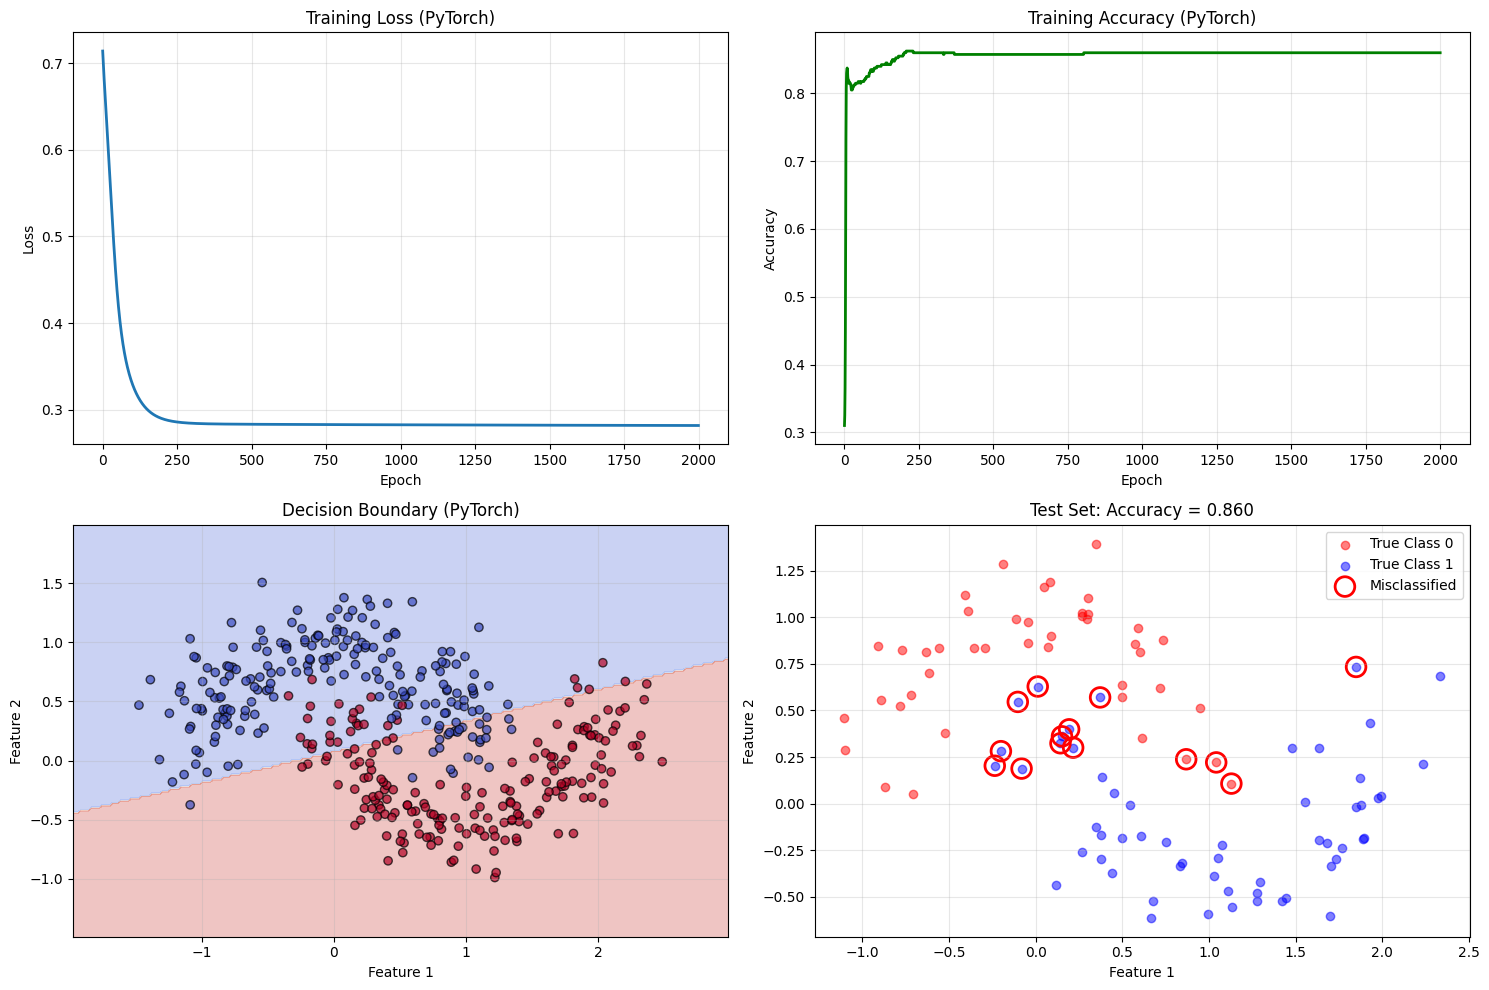

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss history
ax = axes[0, 0]
ax.plot(loss_history, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (PyTorch)')
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy history
ax = axes[0, 1]
ax.plot(accuracy_history, linewidth=2, color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy (PyTorch)')
ax.grid(True, alpha=0.3)

# Plot 3: Decision boundary
ax = axes[1, 0]
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = model(grid_tensor)
    Z = (Z > 0.5).float().numpy().reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.7, edgecolors='black')
ax.set_title('Decision Boundary (PyTorch)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)

# Plot 4: Test set predictions
ax = axes[1, 1]
for i, label in enumerate([0, 1]):
    mask = y_test == label
    ax.scatter(X_test[mask, 0], X_test[mask, 1],
               c=['red', 'blue'][i], label=f'True Class {i}', alpha=0.5)
with torch.no_grad():
    y_pred_test_np = y_pred_test.numpy()
    misclassified = (y_pred_test_np.flatten() > 0.5).astype(int) != y_test
ax.scatter(X_test[misclassified, 0], X_test[misclassified, 1],
           s=200, facecolors='none', edgecolors='red', linewidths=2,
           label='Misclassified')
ax.set_title(f'Test Set: Accuracy = {test_accuracy.item():.3f}')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()